## L1-Penalized GP with Bilby

*Questions*


*To Do*

    - 0.2 < acceptance fraction < 0.5
    - look at trace plots and how many samples are needed for convergence

*Notes*

- In BL, using 10,000 iterations with 1000 iterations of burn-in. 
- Gamma prior on lambda squared with r = 1, delta = 1.78
- For beta: using $\nu$ to calculate
- For tau_sq, using $\zeta$ to calculate


### Hidden

\begin{align*}
& p(y, \beta, \tau^2, \sigma^2_N, \sigma^2_{GP}, \ell, \lambda) \\
&= \frac{\exp\!\left(
 -\frac12 (y - X\beta)^\top (K + \sigma^2_N I_n)^{-1} (y - X\beta)
\right)}
{\sqrt{(2\pi)^n |K + \sigma^2_N I_n|}} \\[6pt]
&\quad \times \frac{\exp\!\left(-\frac12 \beta^\top (\sigma^2_N D_\tau)^{-1} \beta \right)}
{(2\pi)^{p/2} |\sigma^2_N D_\tau|^{1/2}} \\[6pt]
&\quad \times \prod_{j=1}^p \frac{\lambda^2}{2} \exp\!\left( -\frac{\lambda^2}{2} \tau_j^2 \right) \\[6pt]
&\quad \times \frac{\beta_{\text{noise}}^{\alpha_{\text{noise}}}}{\Gamma(\alpha_{\text{noise}})}
(\sigma^2_N)^{-\alpha_{\text{noise}}-1} \exp\!\left( -\frac{\beta_{\text{noise}}}{\sigma^2_N} \right) \\[6pt]
&\quad \times \frac{\beta_{\text{GP}}^{\alpha_{\text{GP}}}}{\Gamma(\alpha_{\text{GP}})}
(\sigma^2_{GP})^{-\alpha_{\text{GP}}-1} \exp\!\left( -\frac{\beta_{\text{GP}}}{\sigma^2_{GP}} \right) \\[6pt]
&\quad \times \frac{1}{\ell \, \sigma_\ell \sqrt{2\pi}}
\exp\!\left( -\frac{(\log \ell - \mu_\ell)^2}{2\sigma_\ell^2} \right) \\[6pt]
&\quad \times \frac{b_\lambda^{a_\lambda}}{\Gamma(a_\lambda)} \lambda^{a_\lambda - 1} e^{-b_\lambda \lambda}
\end{align*}

Posterior:
$$p(\beta, \tau^2, \sigma^2_N, \sigma^2_{GP}, \ell, \lambda \mid y) \propto p(y | \beta, \sigma^2_N, \sigma^2_{GP}, \ell) \times p(\beta | \sigma^2_N, \tau^2) \times \prod_{j=1}^p p(\tau_j^2 | \lambda) \times p(\sigma^2_N) \times p(\sigma^2_{GP}) \times p(\ell) \times p(\lambda)$$

In [24]:
## to save time plotting


# fig = plt.Figure() # notice the capital F
# sns.pairplot(.....)
# plt.savefig(.....)
# plt.close()


# pairplot(corner = True) # only plots half of symmetrical plot


### Data

In [25]:
sampler_name = "emcee"
desc = "long"
id = 1
numwalkers = 25
numsteps = 20
numburn = 2
a_val = 3


In [26]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bilby
from bilby.core.utils import random
import json
import scipy.special
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# where / how to save files
label = f"{sampler_name}{id}_{desc}"
outdir = f"{numwalkers}walkers"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)
random.seed(123)

In [27]:
### --- to load diabetes data ---
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
X = diabetes.data

selected_features = ['bmi', 'bp', 's1']
X = X[selected_features]

label_names = diabetes.feature_names
y = diabetes.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=22)

scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain) # fit and scale training data
Xtest = scaler.transform(Xtest) # scale test data

### MCMC

In [28]:
# helper function to compute the RBF kernel
def rbf_kernel(X, ell, sigma_gp):
    N = X.shape[0]
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            diff = (X[i] - X[j]) / ell
            K[i, j] = sigma_gp**2 * np.exp(-0.5 * np.dot(diff, diff))
    return K

In [29]:
# custom likelihood for penalized GP regression

class PenalizedGPLikelihood(bilby.Likelihood):
    def __init__(self, X, y):
        # store data
        self.X = np.asarray(X)
        self.y = np.asarray(y)

        # define parameters
        parameters = {}

        for i in range(self.X.shape[1]):
            parameters[f"ell{i}"] = None # lengthscales (ells)     
            parameters[f"nu{i}"] = None # nu: random variable for beta calculation
            parameters[f"zeta{i}"] = None # zeta: random variable for tau calculation

        # noise parameters
        parameters["inv_sigma_noise"] = None # remember this is gamma not inverse gamma, so use (alpha, 1/b)
        parameters["inv_sigma_gp"] = None # remember this is gamma not inverse gamma, so use (alpha, 1/b)
        parameters["lambda2"] = None # lambda_squared 

        super().__init__(parameters=parameters)


    def log_likelihood(self):

        # extract parameters
        inv_sigma_noise = self.parameters["inv_sigma_noise"]
        inv_sigma_gp = self.parameters["inv_sigma_gp"]
        ells = np.array([self.parameters[f"ell{i}"] for i in range(self.X.shape[1])])
        lbda2 = self.parameters["lambda2"] # sample lambda squared

        # --- transformers ---
        nus = np.array([self.parameters[f"nu{i}"] for i in range(self.X.shape[1])]) # random var for beta
        zetas = np.array([self.parameters[f"zeta{i}"] for i in range(self.X.shape[1])]) 
        
        # calculate n and p
        n = self.X.shape[0]
        p = self.X.shape[1]

        # --- transform sampled gamma to desired inverse gamma ---
        sigma_gp = 1/inv_sigma_gp if inv_sigma_gp is not None else None
        sigma_noise = 1/inv_sigma_noise if inv_sigma_noise is not None else None

        # --- transform zetas to tau^2 ---
        # each tau^2 \sim expoential(\lambda^2 / 2)
        if (zetas is not None and lbda2 is not None):
            tau_sqs = (2 * zetas) / lbda2

        # --- transform nu to beta ---                   
        if (nus is not None and tau_sqs is not None and sigma_noise is not None):
            betas = nus * np.sqrt(tau_sqs) * sigma_noise 
        
        C = rbf_kernel(self.X, ells, sigma_gp) # calculate covariance matrix C
        residuals = self.y - self.X @ betas  # calculate residuals
        D = np.diag(tau_sqs) # calculate diagonal matrix D

        # compute ahead of time
        sigma2_D = sigma_noise**2 * D
        

        # --- log likelihood components ---
        log_lik_gp = (
            -0.5 * n * np.log(2 * np.pi) 
            -0.5 * np.linalg.slogdet(C + sigma_noise**2 * np.eye(n))[1]
            -0.5 *(residuals).T @ np.linalg.solve(C + sigma_noise**2 * np.eye(n), residuals))

        # rewritten to avoid inversion of D
        if np.any(sigma2_D == 0):
            log_lik_beta = (
                -0.5 * p * np.log(2 * np.pi)
                -0.5 * np.linalg.slogdet(sigma_noise**2 * D)[1]
                -0.5 * betas.T @ np.linalg.solve(sigma_noise**2 * D, betas)
            )
        else:  
            inv_sigma2_D = 1 / sigma2_D
            quadratic = np.dot((betas.ravel()**2), inv_sigma2_D)
            logdet = np.sum(np.log(sigma2_D))
            
            log_lik_beta = (
                -0.5 * p * np.log(2 * np.pi)
                -0.5 * logdet
                -0.5 * quadratic)
        
        return log_lik_gp + log_lik_beta


In [30]:
# make priors
priors = dict()

priors["inv_sigma_noise"] = bilby.core.prior.Gamma(1, 1, "inv_sigma_noise")  
priors["inv_sigma_gp"] = bilby.core.prior.Gamma(1, 1, "inv_sigma_gp")  
priors["lambda2"] = bilby.core.prior.Gamma(1.0, 1.78, name="lambda2") # positive

for i in range(Xtrain.shape[1]):
    priors[f"zeta{i}"] = bilby.core.prior.Exponential(1, f"zeta{i}") # exponential with mean 1 = rate 1
    priors[f"ell{i}"] = bilby.core.prior.LogNormal(0, 1, f"ell{i}") # define log-normal priors for each lengthscale
    priors[f"nu{i}"] = bilby.core.prior.Normal(0,1, f"nu{i}") # standard normal for nu

# define the likelihood function that we defined earlier
likelihood = PenalizedGPLikelihood(
    X = Xtrain,
    y = ytrain)

In [31]:
# run MCMC sampler
result = bilby.run_sampler(
    likelihood=likelihood, # likelihood function
    priors=priors, # prior distributions
    sampler=sampler_name, # other options for mcmc are emcee, zeus, , pyemcee, ptemcee, bilby-mcmc 
    nwalkers = numwalkers , # need > 2 x number of parameters
    nsteps = numsteps,
    nburn = numburn,
    sampler_kwargs = dict(a=a_val),
    outdir=outdir,
    label=label)

14:42 bilby INFO    : Running for label 'emcee1_long', output will be saved to '25walkers'
14:42 bilby INFO    : Analysis priors:
14:42 bilby INFO    : inv_sigma_noise=Gamma(k=1, theta=1, name='inv_sigma_noise', latex_label='inv_sigma_noise', unit=None, boundary=None)
14:42 bilby INFO    : inv_sigma_gp=Gamma(k=1, theta=1, name='inv_sigma_gp', latex_label='inv_sigma_gp', unit=None, boundary=None)
14:42 bilby INFO    : lambda2=Gamma(k=1.0, theta=1.78, name='lambda2', latex_label='lambda2', unit=None, boundary=None)
14:42 bilby INFO    : zeta0=Exponential(mu=1, name='zeta0', latex_label='zeta0', unit=None, boundary=None)
14:42 bilby INFO    : ell0=LogNormal(mu=0, sigma=1, name='ell0', latex_label='ell0', unit=None, boundary=None)
14:42 bilby INFO    : nu0=Normal(mu=0, sigma=1, name='nu0', latex_label='nu0', unit=None, boundary=None)
14:42 bilby INFO    : zeta1=Exponential(mu=1, name='zeta1', latex_label='zeta1', unit=None, boundary=None)
14:42 bilby INFO    : ell1=LogNormal(mu=0, sigma=1,

In [32]:
result.posterior

,inv_sigma_noise,inv_sigma_gp,lambda2,zeta0,ell0,nu0,zeta1,ell1,nu1,zeta2,ell2,nu2,log_likelihood,log_prior
0,0.134839,0.313127,0.100427,3.759628,0.602576,-1.530759,2.051066,1.124564,0.177154,0.483693,1.511252,-0.514260,-43168.836534,-14.452785
1,0.134839,0.313127,0.100427,3.759628,0.602576,-1.530759,2.051066,1.124564,0.177154,0.483693,1.511252,-0.514260,-18064.780911,-15.059774
2,0.134839,0.313127,0.100427,3.759628,0.602576,-1.530759,2.051066,1.124564,0.177154,0.483693,1.511252,-0.514260,-989801.921076,-11.640925
3,0.134839,0.313127,0.100427,3.759628,0.602576,-1.530759,2.051066,1.124564,0.177154,0.483693,1.511252,-0.514260,-184093.027047,-8.718095
4,0.134839,0.313127,0.100427,3.759628,0.602576,-1.530759,2.051066,1.124564,0.177154,0.483693,1.511252,-0.514260,-25858.884658,-15.495715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,0.499070,0.468802,0.809939,0.710904,3.091264,0.130633,0.477687,3.318949,0.028346,2.069322,2.867121,-1.023758,-115779.591341,-16.214855
446,0.406848,0.364896,0.667674,1.397513,3.301428,-0.335909,0.632577,3.028936,0.147630,1.739386,4.054240,-0.869769,-68811.477675,-23.650988
447,0.406848,0.364896,0.667674,1.397513,3.301428,-0.335909,0.632577,3.028936,0.147630,1.739386,4.054240,-0.869769,-274436.353052,-15.399109
448,0.408074,0.344045,0.714172,1.372765,3.521101,-0.395357,0.619992,3.308098,0.090753,1.972926,4.120353,-0.908423,-22636.216270,-16.495614


In [33]:
# create new dataframe to store results
result_tab = result.posterior.copy()

# calculate tau_sq from samples
for i in range(X.shape[1]):
    zetas = result_tab[f"zeta{i}"].values
    tau_sqs = (2 * zetas) / result_tab["lambda2"].values
    result_tab["lambda"] = np.sqrt(result_tab["lambda2"])
    result_tab[f"tau_sq{i}"] = tau_sqs

# calculate beta from samples
for i in range(X.shape[1]):
    nus = result_tab[f"nu{i}"].values
    result_tab["sigma_noise"] = 1 / result_tab["inv_sigma_noise"].values
    tau_sqs = result_tab[f"tau_sq{i}"].values
    betas = nus * np.sqrt(tau_sqs) * result_tab["sigma_noise"].values
    result_tab[f"beta{i}"] = betas


clean_tab = result_tab.copy()
drop_cols = [f"zeta{i}" for i in range(X.shape[1])] + ["lambda2", "inv_sigma_noise", "inv_sigma_gp"] + [f"nu{i}" for i in range(X.shape[1])]
clean_tab = clean_tab.drop(columns=drop_cols) # drop unneeded columns
clean_tab = clean_tab.reindex(sorted(clean_tab.columns), axis=1) # sort columns alphabetically
    

In [34]:
type(result_tab)


pandas.core.frame.DataFrame

In [35]:
result.plot_walkers()


In [36]:
# calculate acceptance fraction

import pickle

print("bilby version:", bilby.__version__)


with open(f"{numwalkers}walkers/{sampler_name}_{sampler_name}{id}_{desc}/sampler.pickle", "rb") as f:
    sampler = pickle.load(f)

af = sampler.acceptance_fraction
print("Per-walker acceptance fractions:", af)
print("Mean acceptance fraction:", af.mean())


bilby version: 2.6.0
Per-walker acceptance fractions: [0.05 0.   0.55 0.25 0.1  0.2  0.55 0.   0.1  0.1  0.35 0.25 0.1  0.35
 0.2  0.25 0.15 0.3  0.45 0.55 0.4  0.2  0.45 0.2  0.45]
Mean acceptance fraction: 0.262


In [37]:
clean_tab.median()

beta0                 -0.166921
beta1                 -0.106076
beta2                 -1.172593
ell0                   1.371670
ell1                   1.114121
ell2                   1.574768
lambda                 1.083998
log_likelihood   -142518.361787
log_prior            -14.476137
sigma_noise            2.391053
tau_sq0                1.486250
tau_sq1                1.167331
tau_sq2                2.162190
dtype: float64

ValueError: cannot reshape array of size 450 into shape (50,9000)

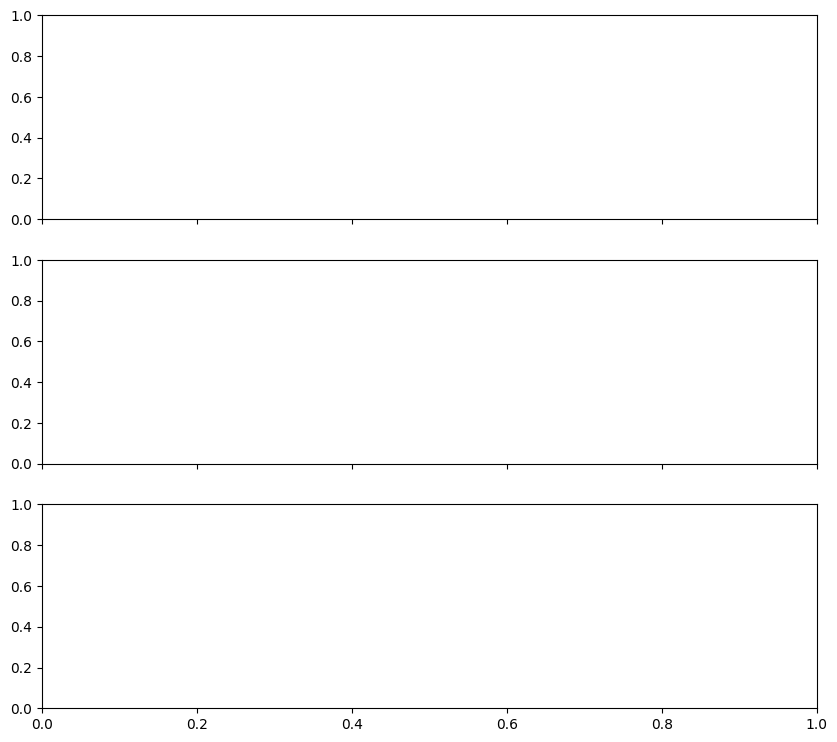

In [38]:
fig, axes = plt.subplots(X.shape[1], 1, figsize=(10, 3*X.shape[1]), sharex=True)

for i in range(X.shape[1]):
    ax = axes[i]
    traces = clean_tab[f"beta{i}"].to_numpy().reshape(50, 9000).T
    ax.plot(traces, alpha=0.5, linewidth=0.5)  # matplotlib will plot each walker as a line
    ax.set_ylim([-60, 60])
    ax.set_title(f"Trace plot for beta{i}")
    ax.set_ylabel(f"beta{i}")

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()